# Model Explainability with SHAP

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import shap
from sklearn.ensemble import RandomForestClassifier

In [3]:
pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
# ART_DIR = Path('../artifacts')
ART_DIR = Path('/content/drive/MyDrive/artifacts')
np.random.seed(42)

## Data and the risk model

We fit a RandomForest on the engineered behavioural features to predict the consensus_loose risk label — the same weak-supervision target and model family used in Notebooks 05 and 09. This model exists purely to be explained; its detection quality was already characterised in Notebook 10. The answer-key labels are loaded only to locate the three real insiders inside the explanations.

In [4]:
fe = pd.read_parquet(ART_DIR / 'cert_engineered_features.parquet').reset_index(drop=True)
gt = pd.read_csv(ART_DIR / 'cert_ground_truth_labels.csv')
feats = [c for c in json.load(open(ART_DIR / 'model_feature_list.json')) if c != 'behavior_cluster']
X = fe[feats].fillna(0)
y = fe['consensus_loose'].astype(int).values
users = fe['user'].tolist()
insiders = gt.loc[gt['insider'] == 1, 'user'].tolist()
len(feats), int(y.sum()), insiders

(31, 90, ['ABB0427', 'KTW0365', 'HFC0492'])

In [5]:
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
rf.fit(X, y)
risk = rf.predict_proba(X)[:, 1]
risk.shape

(1000,)

## SHAP values (exact, TreeExplainer)

TreeExplainer returns one Shapley value per user per feature for the positive (risk) class. We extract that class and its base value; the base value is the model's average output, and each SHAP value is the signed push a feature gives a user away from that average.

In [6]:
explainer = shap.TreeExplainer(rf)
sv = explainer.shap_values(X)
if isinstance(sv, list):
    sv1 = np.array(sv[1]); base = float(np.ravel(explainer.expected_value)[1])
else:
    sv = np.array(sv)
    if sv.ndim == 3:
        sv1 = sv[:, :, 1]; base = float(np.ravel(explainer.expected_value)[1])
    else:
        sv1 = sv; base = float(np.ravel(explainer.expected_value)[0])
sv1.shape, round(base, 4)

((1000, 31), 0.501)

## Global feature importance

Averaging the absolute SHAP value of each feature across all users ranks the behaviours the model relies on most.

/tmp/ipykernel_479/397757752.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv1, X, plot_type='bar', show=False, max_display=15)


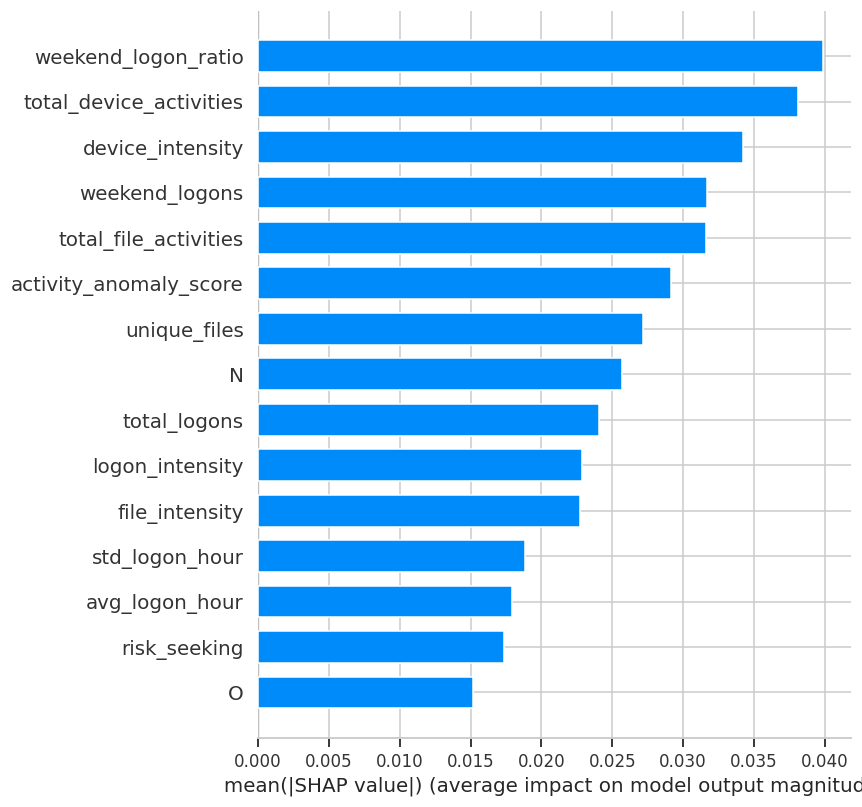

In [7]:
plt.figure()
shap.summary_plot(sv1, X, plot_type='bar', show=False, max_display=15)
plt.tight_layout(); plt.show()

/tmp/ipykernel_479/243814701.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv1, X, show=False, max_display=15)


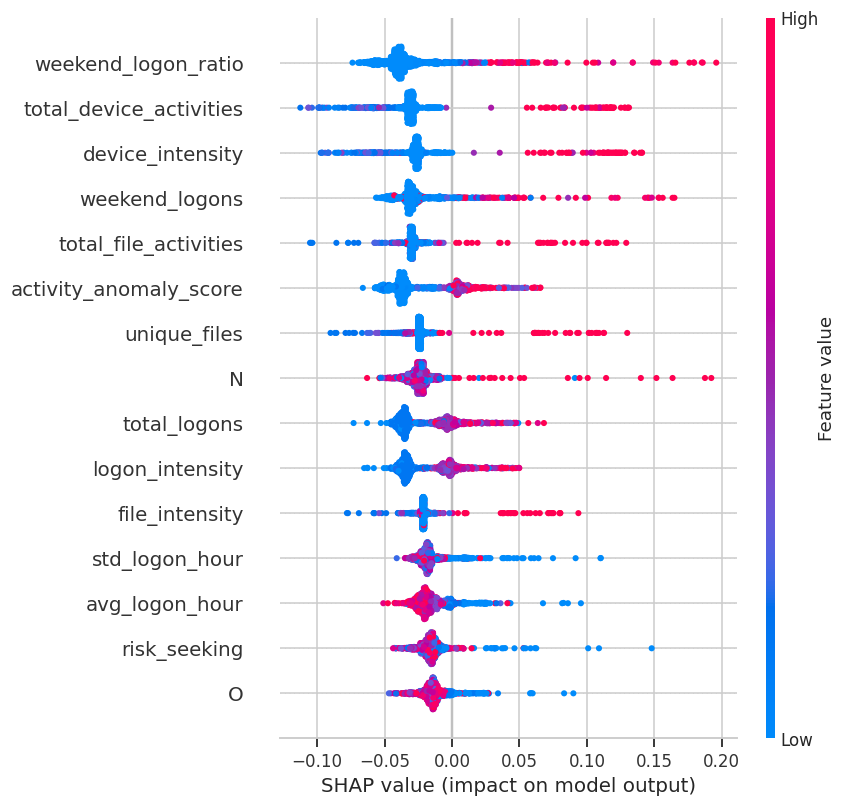

In [8]:
plt.figure()
shap.summary_plot(sv1, X, show=False, max_display=15)
plt.tight_layout(); plt.show()

## Feature dependence

A dependence plot shows how one feature's contribution changes across its value range, revealing the risk threshold the model has effectively learned.

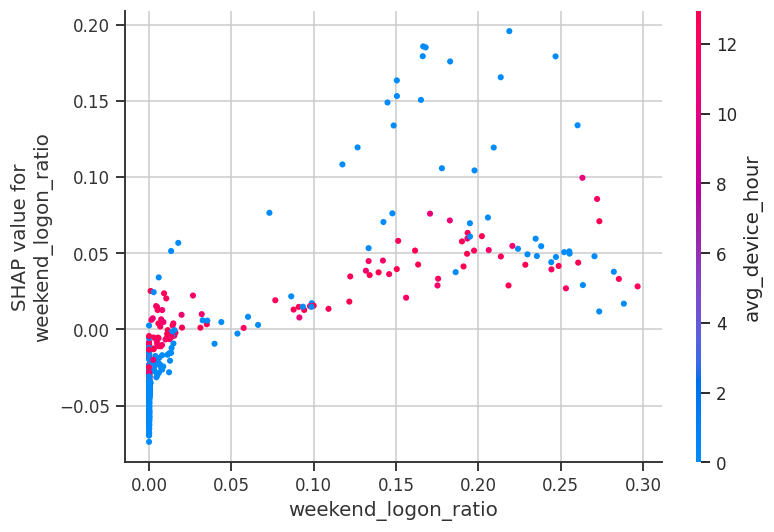

In [9]:
top_feature = pd.Series(np.abs(sv1).mean(0), index=feats).idxmax()
shap.dependence_plot(top_feature, sv1, X, show=False)
plt.tight_layout(); plt.show()

## Per-insider explanations

For each real insider we show the features pushing their risk up (red) and down (blue). This is the case-file an analyst would read alongside an alert.

In [12]:
def explain_user(user, topn=10):
    i = users.index(user)
    contrib = pd.Series(sv1[i], index=feats).sort_values()
    top = pd.concat([contrib.head(topn // 2), contrib.tail(topn // 2)])
    colors = ['tab:red' if v > 0 else 'blue' for v in top.values]
    plt.figure(figsize=(8, 5))
    plt.barh(top.index, top.values, color=colors)
    plt.axvline(0, color='k', lw=0.8)
    plt.title(f'SHAP explanation for {user}  (risk score {risk[i]:.3f})')
    plt.xlabel('SHAP value  (>0 raises risk, <0 lowers risk)')
    plt.tight_layout(); plt.show()

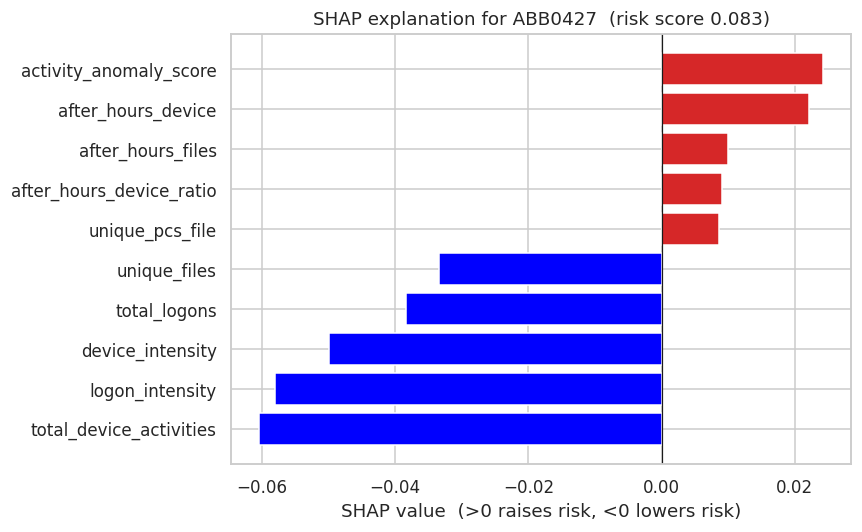

In [13]:
explain_user('ABB0427')  # scenario 1 — after-hours wikileaks exfiltration

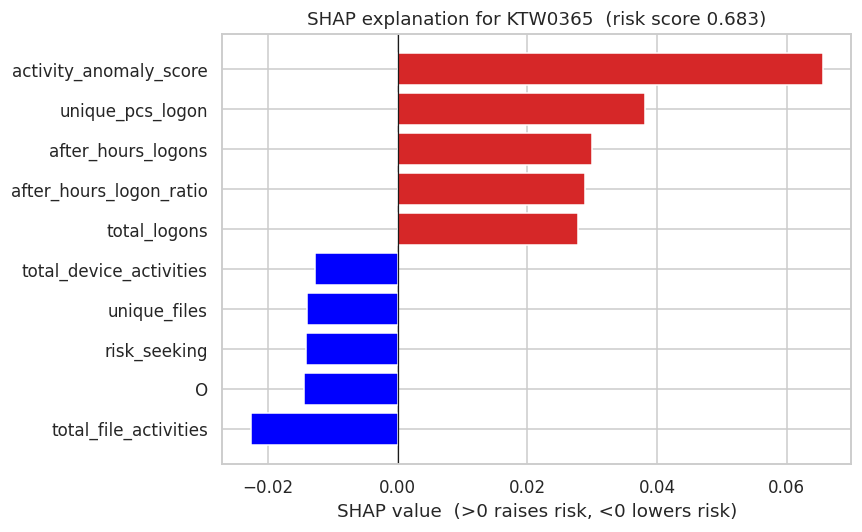

In [14]:
explain_user('KTW0365')  # scenario 3 — disgruntled sysadmin keylogger

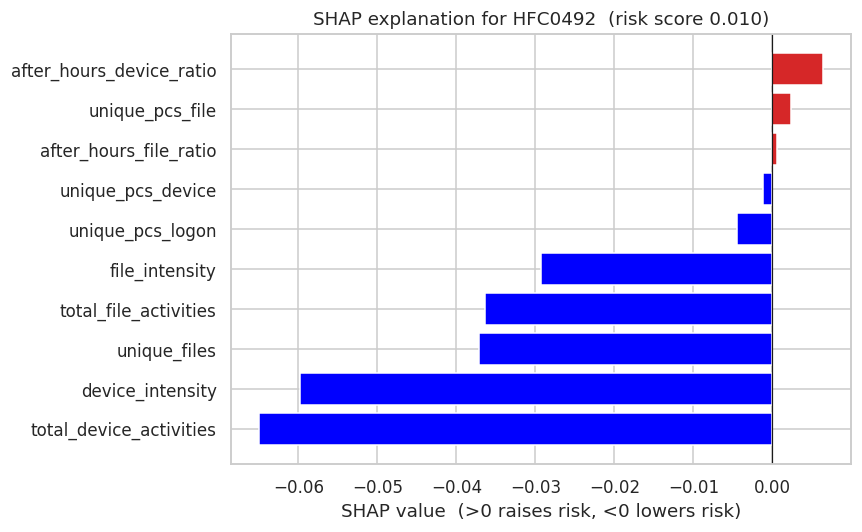

In [15]:
explain_user('HFC0492')  # scenario 2 — slow thumb-drive exfiltration

Each plot is a per-user case file — red bars are behaviours raising the score, blue bars lower it. The value of SHAP here is diagnostic honesty: it shows, feature by feature, how much genuine risk evidence the proxy-trained model actually finds for each insider. Where the positive bars are short, the model has little to act on — which is exactly why the proxy-trained models in Notebook 10 rank that insider poorly.

Summing each user's absolute SHAP values gives their total *evidence mass* — how much the features collectively move the model. Comparing the insiders to the population makes the detectability gap quantitative.

In [16]:
mass = np.abs(sv1).sum(axis=1)
gap = pd.DataFrame({'user': users, 'evidence_mass': mass, 'risk_score': risk})
ins_gap = gap.set_index('user').loc[insiders].copy()
ins_gap['pop_median'] = np.median(mass)
ins_gap['pop_p90'] = np.quantile(mass, 0.90)
ins_gap['pct_of_pop'] = [round(float((mass < m).mean() * 100), 1) for m in ins_gap['evidence_mass']]
ins_gap.round(4)

,evidence_mass,risk_score,pop_median,pop_p90,pct_of_pop
user,,,,,
ABB0427,0.5662,0.0833,0.5032,0.5793,88.2
KTW0365,0.4704,0.6833,0.5032,0.5793,2.0
HFC0492,0.5097,0.0100,0.5032,0.5793,61.2


## SOC triage table

A deployable view: the highest-risk users, each with the top behaviours driving the score and a ground-truth flag for this benchmark.

In [17]:
order = np.argsort(-risk)[:20]
truth = set(insiders)
rows = []
for i in order:
    drivers = pd.Series(sv1[i], index=feats).sort_values(ascending=False).head(3).index.tolist()
    rows.append({'user': users[i], 'risk_score': round(float(risk[i]), 3),
                 'top_drivers': ', '.join(drivers),
                 'is_real_insider': int(users[i] in truth)})
triage = pd.DataFrame(rows)
triage

,user,risk_score,top_drivers,is_real_insider
0,MAT0892,0.983,"device_intensity, total_device_activities, tot...",0
1,PHJ0041,0.980,"device_intensity, total_device_activities, aft...",0
2,WCR0044,0.980,"device_intensity, total_device_activities, tot...",0
3,HBM0350,0.973,"total_device_activities, device_intensity, tot...",0
4,BJW0369,0.970,"device_intensity, total_device_activities, tot...",0
5,RRF0873,0.970,"device_intensity, total_file_activities, total...",0
6,JHF0505,0.963,"total_device_activities, device_intensity, tot...",0
7,LGS0292,0.960,"device_intensity, total_device_activities, tot...",0
8,PBM0839,0.957,"device_intensity, total_device_activities, tot...",0
9,XMB0730,0.957,"device_intensity, total_device_activities, tot...",0


In [18]:
imp = (pd.Series(np.abs(sv1).mean(0), index=feats)
         .sort_values(ascending=False).rename('mean_abs_shap'))
imp.to_csv(ART_DIR / 'shap_global_importance.csv')
triage.to_csv(ART_DIR / 'soc_triage_table.csv', index=False)
ins_gap.round(4).to_csv(ART_DIR / 'insider_evidence_mass.csv')
sorted(p.name for p in ART_DIR.glob('shap_*')) + ['soc_triage_table.csv', 'insider_evidence_mass.csv']

['shap_global_importance.csv',
 'soc_triage_table.csv',
 'insider_evidence_mass.csv']